# Phần 1: Khám Phá Dữ Liệu (Exploratory Data Analysis - EDA)

## Mục tiêu của phase EDA:
- **Chốt cột dùng cho rich_text:** Xác định các trường text quan trọng (plot, genres, keywords) để nối lại làm data embedding.
- **Chốt rule lọc phim trước khi embed:** Loại bỏ phim rác, thiếu thông tin cốt lõi, rating quá thấp hoặc không đủ dữ kiện.
- **Chốt metadata để trả API:** Xác định các cột thông tin sẽ lưu trong ChromaDB/Metadata để frontend có đủ thông tin hiển thị (title, year, poster, rating, director...).


## 1. Load Dữ Liệu & Kiểm Tra Schema
- Load dataset từ file CSV.
- Kiểm tra kích thước dữ liệu (`shape`).
- Xem qua các cột (`columns`) và kiểu dữ liệu (`dtypes`).
- Đối chiếu với data plan ban đầu.


In [7]:
# !pip install numpy pandas scikit-learn seaborn

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import ast 
import re 
import ast
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


data_path = "../backend/data/processed/movies_final.csv"
df = pd.read_csv(data_path)

print(f"Kích thước tập dữ liệu: {df.shape}")
print(f"\n--------Kiểu dữ liệu (dtypes)--------")
print(df.dtypes)

print(f"\n--- Top 3 rows ---")
display(df.head(3))

Kích thước tập dữ liệu: (35798, 11)

--------Kiểu dữ liệu (dtypes)--------
imdb_id          str
title            str
year         float64
genres           str
runtime      float64
rating       float64
votes          int64
director         str
cast             str
plots            str
rich_text        str
dtype: object

--- Top 3 rows ---


,imdb_id,title,year,genres,runtime,rating,votes,director,cast,plots,rich_text
0,tt0035423,Kate & Leopold,2001.0,"['Comedy', 'Fantasy', 'Romance']",118.0,6.4,94017,James Mangold,"Meg Ryan, Hugh Jackman, Liev Schreiber",When her scientist ex-boyfriend discovers a po...,Title: Kate & Leopold (2001.0)\nGenres: ['Come...
1,tt0038687,Let There Be Light,1980.0,"['Documentary', 'War']",58.0,7.4,2178,NaN,Walter Huston,The final entry in a trilogy of films produced...,Title: Let There Be Light (1980.0)\nGenres: ['...
2,tt0062285,"Oh, Sun",1970.0,['Drama'],98.0,7.4,1088,Med Hondo,"Robert Liensol, Théo Légitimus, Ambroise M'Bia",An educated native of Mauritania tries to find...,"Title: Oh, Sun (1970.0)\nGenres: ['Drama']\nRa..."


## 2. Kiểm tra chất lượng dữ liệu (Data Quality Audit)
Kiểm tra tỷ lệ dữ liệu khuyết thiếu (Missing/Null) và dữ liệu trùng lặp (Duplicates). Dù đã qua bước Data Pipeline, ta vẫn cần verify lại tính toàn vẹn của dữ liệu.


In [3]:
print("Shaepe: ", df.shape)
print("Columns: ", df.columns.tolist())
print("\n Dtypes: \n", df.dtypes)
print("\nMissing ratio (%):\n", (df.isnull().mean() * 100).sort_values(ascending=False).head(20))
print("\nDuplicate imdb_id:", df["imdb_id"].duplicated().sum() if "imdb_id" in df.columns else "no imdb_id")

Shaepe:  (35798, 11)
Columns:  ['imdb_id', 'title', 'year', 'genres', 'runtime', 'rating', 'votes', 'director', 'cast', 'plots', 'rich_text']

 Dtypes: 
 imdb_id          str
title            str
year         float64
genres           str
runtime      float64
rating       float64
votes          int64
director         str
cast             str
plots            str
rich_text        str
dtype: object

Missing ratio (%):
 cast         5.366222
director     0.173194
runtime      0.092184
year         0.000000
title        0.000000
imdb_id      0.000000
genres       0.000000
votes        0.000000
rating       0.000000
plots        0.000000
rich_text    0.000000
dtype: float64

Duplicate imdb_id: 0


## Thống kê coverage và độ dài plot

In [4]:
df["plots"] = df["plots"].fillna("").astype(str)
df["plot_len_char"] = df["plots"].str.len()
df["plot_len_word"] = df["plots"].str.split().str.len()

print(df[["plot_len_char", "plot_len_word"]].describe(percentiles=[.5,.75,.9,.95,.99]))
print("Short plot (<50 chars):", (df["plot_len_char"] < 50).sum())
print("Empty plot:", (df["plot_len_char"] == 0).sum())

       plot_len_char  plot_len_word
count   35798.000000   35798.000000
mean      274.813509      46.819906
std       154.029978      26.445817
min        11.000000       2.000000
50%       234.000000      40.000000
75%       356.000000      61.000000
90%       470.000000      81.000000
95%       579.000000      99.000000
99%       799.030000     137.000000
max      1000.000000     185.000000
Short plot (<50 chars): 35
Empty plot: 0


In [5]:
df["rich_text"] = df["rich_text"].fillna("").astype(str)
df["rich_text_len_char"] = df["rich_text"].str.len()
df["rich_text_len_word"] = df["rich_text"].str.split().str.len()

print(df[["rich_text_len_char", "rich_text_len_word"]].describe(percentiles=[.5,.75,.9,.95,.99]))
print("Rich text (<50 chars):", (df["rich_text_len_char"] < 50).sum())
print("Rich text :", (df["plot_len_char"] == 0).sum())

       rich_text_len_char  rich_text_len_word
count        35798.000000        35798.000000
mean           444.607296           69.657076
std            155.153421           26.635597
min            133.000000           17.000000
50%            404.000000           63.000000
75%            528.000000           84.000000
90%            642.000000          104.000000
95%            751.000000          122.000000
99%            970.000000          160.000000
max           1192.000000          211.000000
Rich text (<50 chars): 0
Rich text : 0


## Nhận xét về length của rich_text cho phần model: 
*Chú ý: Trong tiếng anh `1 word`=`1.4 tokens`*
- Có tới 99% là 160 từ. Tức là chỉ có 1% nằm trong mốc từ 225 tới 295 tokens, nên việc sử dụng model `all-MiniLM-L6-v2` là hợp lí (256 tokens). 

- Tỷ lệ mất mát dữ liệu: chỉ có chưa đây 1% số lượng phim bị cắt phần đuôi. Phần đuôi là plots nên việt mất mát nãy cũng ko có tính ý nghĩa lớn lắm, nên ở đây việc lựa chọn model là phù hợp. 


- Ngoài ra, có thể thấy là dữ liệu hầu hết khá sách khi không có outlieers cũng như là không có rỗng 

## Phân phối theo năm/thập kỷ

count    35798.000000
mean      2007.166853
std         14.334682
min       1970.000000
25%       1999.000000
50%       2011.000000
75%       2018.000000
max       2026.000000
Name: year, dtype: float64


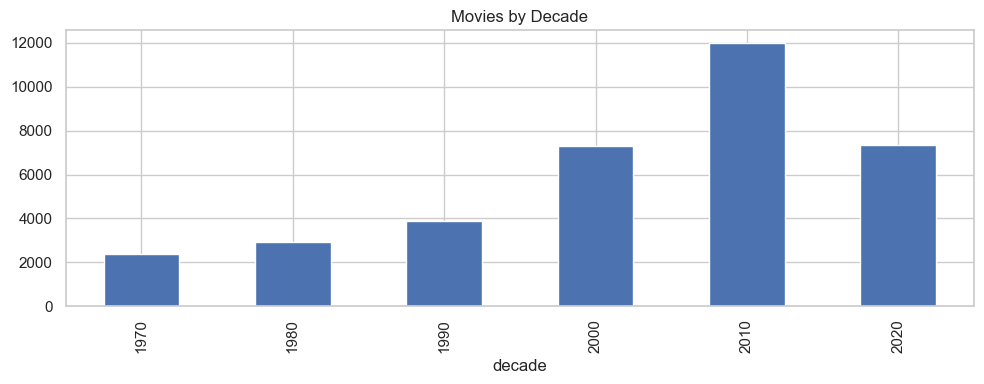

In [6]:
if "year" in df.columns:
    df_year = df.dropna(subset=["year"]).copy()
    df_year["year"] = pd.to_numeric(df_year["year"], errors="coerce")
    df_year = df_year.dropna(subset=["year"])
    df_year["decade"] = (df_year["year"] // 10 * 10).astype(int)

    print(df_year["year"].describe())
    df_year["decade"].value_counts().sort_index().plot(kind="bar", figsize=(10,4), title="Movies by Decade")
    plt.tight_layout()
    plt.show()

## Nhận xét: 

- Có xu hướng tăng dần số bộ phim qua các thập niên. Cho thấy ngành công nghiệp điện ảnh sản xuất nhiều hơn trong kỉ nguyên hiện tại. Ngoài ra, với sự xuất hiện của AI thì việc làm phim càng trở nên phát triển hơn khi AI có thể thực hiện các task mà trước đó tốn rất nhiều thời gian. 

- Ở thập niên 2020 chỉ mới bằng một nữa 2010 là vì hiện tại chỉ đang là năm 2026 chưa hết thập niên, nên đây ko phải là lỗi 

-> **Kết luận:** dữ liệu có sự chênh lệch, nhưng mang tính thực tế 

## Phân tích genres (top genre + số genre/phim)

Top 20 genres: [('Drama', 21114), ('Comedy', 12349), ('Action', 6467), ('Crime', 6082), ('Romance', 5971), ('Thriller', 5252), ('Adventure', 3612), ('Horror', 3520), ('Mystery', 2913), ('Documentary', 2400), ('Biography', 2261), ('Fantasy', 1811), ('History', 1554), ('Animation', 1516), ('Family', 1428), ('Sci-Fi', 1340), ('Music', 1247), ('Sport', 791), ('War', 750), ('Musical', 448)]


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9032\3975919149.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=genres, palette='viridis')


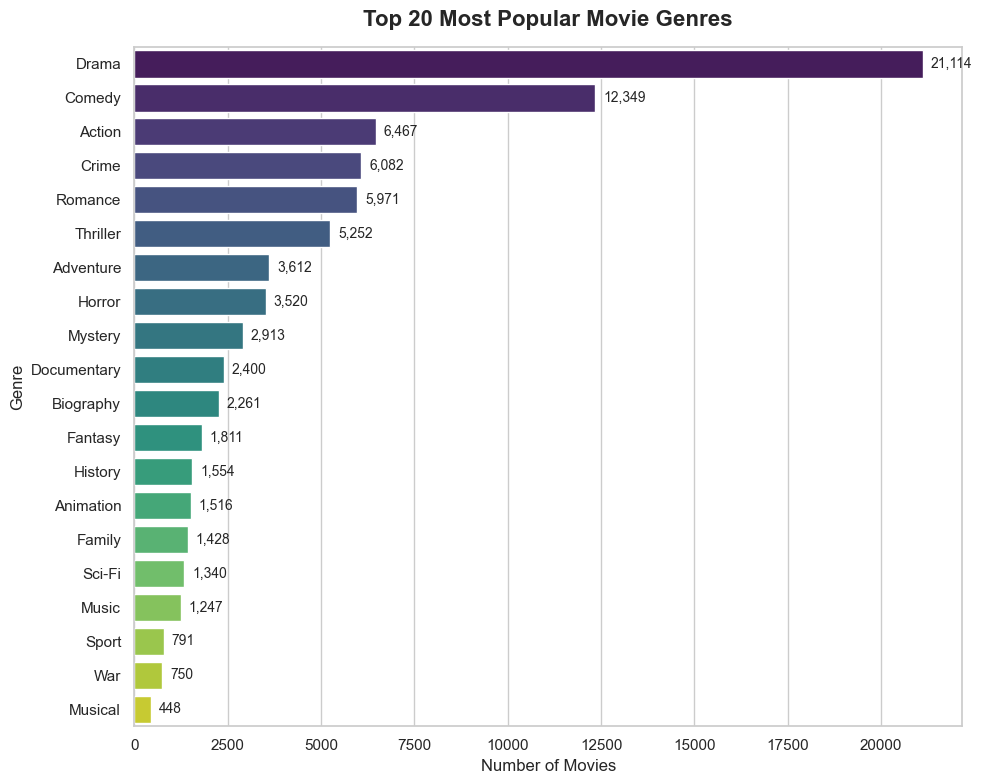

In [9]:
def parse_genres(x):
    if pd.isna(x): return []
    if isinstance(x, list): return x
    x = str(x).strip()
    try:
        v = ast.literal_eval(x)
        if isinstance(v, list): return [str(i).strip() for i in v]
    except:
        pass
    return [i.strip() for i in x.split(",") if i.strip()]

if "genres" in df.columns:
    g = df["genres"].apply(parse_genres)
    all_g = [i for row in g for i in row]
    top = Counter(all_g).most_common(20)
    print("Top 20 genres:", top)
    df["genre_count"] = g.apply(len)
    
    # Tách label (tên thể loại) và value (số lượng) từ list 'top'
    genres = [item[0] for item in top]
    counts = [item[1] for item in top]
    # Thiết lập kích thước khung hình
    plt.figure(figsize=(10, 8))
    
    # Vẽ barplot dạng ngang (x=counts, y=genres)
    # Dùng palette 'viridis' hoặc 'crest' của seaborn để màu sắc đẹp hơn
    sns.barplot(x=counts, y=genres, palette='viridis')
    
    # Thêm tiêu đề và nhãn
    plt.title('Top 20 Most Popular Movie Genres', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Number of Movies', fontsize=12)
    plt.ylabel('Genre', fontsize=12)
    
    # Hiển thị số lượng cụ thể ở cuối mỗi thanh ngang
    for i, count in enumerate(counts):
        plt.text(count + max(counts)*0.01, i, f'{count:,}', va='center', fontsize=10)
        
    plt.tight_layout()
    plt.show()

## Nhận xét: 
- **Drama**  áp đảo **Comedy**, vị trí dẫn đầu có khoảng cách khác biết rất lớn (gần gấp đôi) vị trí thư hai. Mô hình sẽ bị ảnh hưởng rất mạnh bởi hai thể loại này. 

- Các nhóm phổ biến: 
    - Nhóm 1: Drama, Comedy 
    - Nhóm 2: Action, Crime 
    - Nhóm 3: từ Adventure kéo xuống Musical 

- Điều này cho thấy việc tạo thêm một `rich_text` là đúng đắn bởi vì có sự mất cân bằng dữ liệu quá lớn. Nếu dùng đặc trưng này sẽ khiến mô hình bị thiên lệch 

- Khi áp dung ChromaDB, dùng filter để hạn chế sự ảnh hưởng của `Dramma, Commedy`

- Có thể tối ưu câu Insight cho LLM kiểu: `Hãy lưu ý rằng hệ thống database có số lượng phim Drama và Comedy rất lớn. 
Khi phân tích Taste DNA của người dùng, nếu thấy kết quả trả về từ Vector Search bị áp đảo bởi Drama, hãy chủ động chọn lọc và giải thích sâu vào các yếu tố chủ đề ngách (ví dụ: Sci-Fi, Noir, Thriller) ẩn trong cốt truyện để bản báo cáo 
tâm lý mang tính cá nhân hóa cao nhất, tránh đưa ra các gợi ý quá phổ thông.`


## Rating/vote/runtime audit


rating summary:
 count    35798.000000
mean         6.522300
std          0.807212
min          5.000000
25%          5.900000
50%          6.500000
75%          7.100000
max          9.700000
Name: rating, dtype: float64

runtime summary:
 count    35765.000000
mean       107.855054
std         22.847951
min         43.000000
25%         93.000000
50%        103.000000
75%        118.000000
max        776.000000
Name: runtime, dtype: float64
Rating out of [0,10]: 0
Runtime < 40: 0 | Runtime > 240: 37


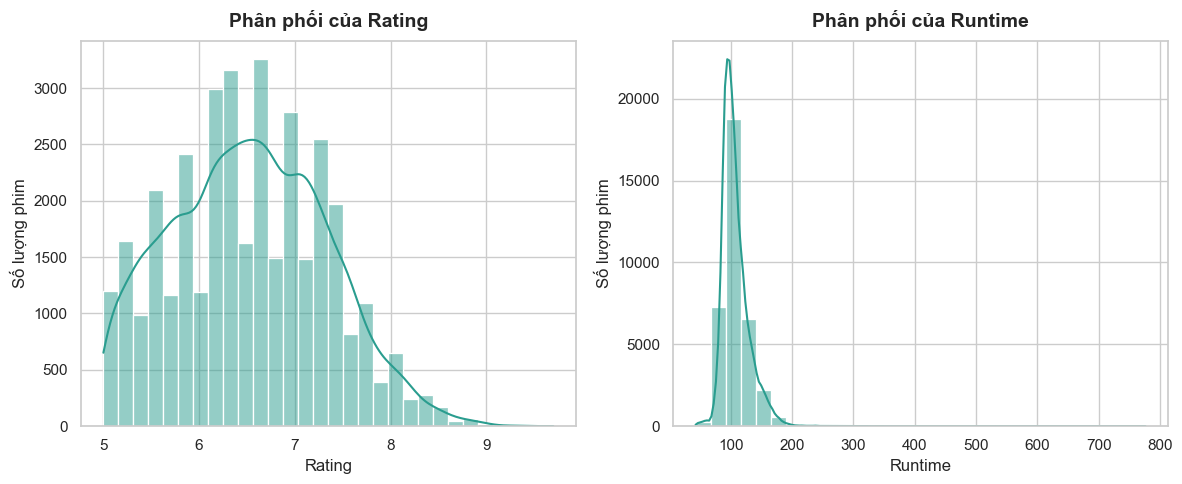

In [11]:
num_cols = [c for c in ["rating", "vote_count", "runtime"] if c in df.columns]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    print(f"\n{c} summary:\n", df[c].describe())

if "rating" in df.columns:
    print("Rating out of [0,10]:", ((df["rating"] < 0) | (df["rating"] > 10)).sum())
if "runtime" in df.columns:
    print("Runtime < 40:", (df["runtime"] < 40).sum(), "| Runtime > 240:", (df["runtime"] > 240).sum())

if len(num_cols) > 0:
    fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 5))
    if len(num_cols) == 1:
        axes = [axes]
        
    for i, c in enumerate(num_cols):
        # Lọc bỏ các giá trị NaN để tránh lỗi khi vẽ
        data_to_plot = df[c].dropna()
        
        # Vẽ Histogram kết hợp đường cong (KDE)
        sns.histplot(data_to_plot, bins=30, kde=True, ax=axes[i], color="#2a9d8f")
        
        # Trang trí biểu đồ
        axes[i].set_title(f'Phân phối của {c.capitalize()}', fontsize=14, fontweight='bold', pad=10)
        axes[i].set_xlabel(c.capitalize(), fontsize=12)
        axes[i].set_ylabel('Số lượng phim', fontsize=12)
    plt.tight_layout()
    plt.show()

## Nhận xét: 

- Lý giải cho việc biểu đồ Rating chỉ có các đánh giá từ **5-10**: ở bước filter đã lọc các phim bị đánh giá thấp để đề xuất những phim tốt cho người dùng. Do đó, chỉ có các đnánh giá cao. 

- Mode của biểu đồ Rating tập trung ở 6.3 - 6.8. Đây là mức phổ biến cho một bộ phim giải trí đạt chuẩn (watchable). Những phim (Masterpiece) số lượng giảm dần rất đẹp theo hình chuông. 

- Về Runtime: có một đỉnh nhọn ở mốc 90-110 phút. Đây là thời lượng chuẩn của một phim chiếu rạp. Ngoài ra còn có cái đuôi dài (long tail). Có thể IMDB đã gán nhầm những phim này thành Movie -> Vì số lượng khá ít nên sẽ cân nhắc việc filter các phim có thời lượng quá 4 tiếng. 

In [12]:
print(f"Số lượng phim hiện tại: {len(df):,}")
df = df[(df["runtime"]>=40) & (df["runtime"]<=240)].reset_index(drop=True)
print(f"Số lượng phim sau khi lọc: {len(df):,}")


Số lượng phim hiện tại: 35,798
Số lượng phim sau khi lọc: 35,728


## Phát hiện trùng theo title-year (soft duplicate)

In [14]:
if {"title","year"}.issubset(df.columns):
    soft_dup = df.duplicated(subset=["title","year"], keep=False).sum()
    print("Soft duplicates (title-year):", soft_dup)
    dup_df = df[df.duplicated(subset=["title","year"], keep=False)].sort_values(["title","year"])
    dup_df.head(20)

# xem qua các phim trùng lặp 
dupes = df[df.duplicated(subset=['title', 'year'], keep=False)]
print("Một vài ví dụ bị trùng lặp:")
display(dupes.sort_values(by=['title', 'year']).head(10))


Soft duplicates (title-year): 110
Một vài ví dụ bị trùng lặp:


,imdb_id,title,year,genres,runtime,rating,votes,director,cast,plots,rich_text,genre_count
20543,tt1554091,A Better Life,2011.0,"['Drama', 'Romance']",98.0,7.2,17106,Chris Weitz,"Demián Bichir, José Julián, Eddie 'Piolin' Sotelo",A gardener in East L.A. struggles to keep his ...,Title: A Better Life (2011.0)\nGenres: ['Drama...,2
23104,tt2027265,A Better Life,2011.0,['Drama'],110.0,6.6,1874,Cédric Kahn,"Guillaume Canet, Leïla Bekhti, Slimane Khettabi","Yann, a cook, and Nadia, a waitress and mother...",Title: A Better Life (2011.0)\nGenres: ['Drama...,1
23745,tt21572042,Aftermath,2024.0,"['Drama', 'Mystery', 'Sci-Fi']",78.0,5.0,4468,Gergö Elekes,"Fruzsina Nagy, Edward Apeagyei, Sally Kirkland",After waking up in the middle of a forest with...,"Title: Aftermath (2024.0)\nGenres: ['Drama', '...",3
25654,tt26545708,Aftermath,2024.0,"['Action', 'Thriller']",97.0,5.2,5271,Patrick Lussier,"Dylan Sprouse, Megan Stott, Mason Gooding","A returning war veteran, stricken with PTSD, g...","Title: Aftermath (2024.0)\nGenres: ['Action', ...",2
15292,tt10192566,Alone,2020.0,"['Drama', 'Horror', 'Thriller']",92.0,5.1,5488,Johnny Martin,"Tyler Posey, Summer Spiro, Donald Sutherland","When an outbreak hits, Aidan barricades himsel...","Title: Alone (2020.0)\nGenres: ['Drama', 'Horr...",3
34042,tt7711170,Alone,2020.0,"['Drama', 'Mystery', 'Thriller']",98.0,6.2,35915,John Hyams,"Jules Willcox, Marc Menchaca, Anthony Heald",A recently widowed traveler is kidnapped by a ...,"Title: Alone (2020.0)\nGenres: ['Drama', 'Myst...",3
18932,tt13751694,Animal,2023.0,"['Action', 'Crime', 'Drama']",204.0,6.2,115838,Sandeep Reddy Vanga,"Ranbir Kapoor, Anil Kapoor, Bobby Deol",The hardened son of a powerful industrialist r...,"Title: Animal (2023.0)\nGenres: ['Action', 'Cr...",3
25575,tt26342791,Animal,2023.0,['Drama'],116.0,6.4,1067,Sofia Exarchou,"Dimitra Vlagopoulou, Flomaria Papadaki, Ahille...","Under the hot Greek sun, animators at an all-i...",Title: Animal (2023.0)\nGenres: ['Drama']\nRat...,1
16569,tt11301946,Beast,2022.0,"['Action', 'Comedy', 'Crime']",155.0,5.2,39318,Nelson Dilipkumar,"Joseph Vijay, Pooja Hegde, K. Selvaraghavan","A former RAW officer, who is among the hostage...","Title: Beast (2022.0)\nGenres: ['Action', 'Com...",3
18427,tt13223398,Beast,2022.0,"['Action', 'Adventure', 'Drama']",93.0,5.6,48583,Baltasar Kormákur,"Liyabuya Gongo, Martin Munro, Daniel Hadebe",A recently widowed man and his two teenage dau...,"Title: Beast (2022.0)\nGenres: ['Action', 'Adv...",3


## Lý giải tại sao có sự trùng lắp: 

- Các bộ phim có cùng tên, cùng năm nhưng khác về quốc gia, nội dung. 

- Có thể là phim tài liệu / phim ngắn cùng tên 

- Ở trong bảng thì có thể thấy được các ộ phim này chỉ có tình cờ chung tên và năm phát hành. Nên cần giữ lại cho bước mô hình. Việc phân biệt trong CSDL Vector sẽ dễ dàng khi chúng ta đã có sẵn `rich_text` chứa các Plot khác nhau. Khi người dùng xem qua danh sách gợi ý, học sẽ đọc phần giải thích của AI và hiểu được bộ phim nói về cái gì. 



## Kiểm tra chất lượng text nhiễu (HTML/ký tự lạ)

In [ ]:
import re

def has_html(s): return bool(re.search(r"<[^>]+>", s))
def noisy_ratio(series, fn): return series.astype(str).apply(fn).mean() * 100

print("Rows with HTML tags (%):", noisy_ratio(df["plots"], has_html))


Rows with HTML tags (%): 0.0


## Lưu vào CSV

In [23]:
eda_final = df.copy()
print("Số lượng phim sau cùng :", len(eda_final))
eda_final.to_csv("../backend/data/processed/movies_final_for_embedding.csv", index=False)
print("Đã lưu file: backend/data/processed/movies_final_for_embedding.csv")

Số lượng phim sau cùng : 35728


Đã lưu file: backend/data/processed/movies_final_for_embedding.csv


## Summary EDA

# Tổng kết quá trình Exploratory Data Analysis (EDA)

Quá trình EDA đã giúp làm sáng tỏ cấu trúc của tập dữ liệu IMDb sau khi được merge với TMDB Plots, đồng thời định hướng rõ ràng cho các bước tiền xử lý chuẩn bị cho Vector Embedding (ChromaDB).

## 1. Phân phối độ dài nội dung (Plot Length)
- **Độ dài trung bình:** Khoảng 47 từ (275 ký tự), lý tưởng để đưa vào các mô hình Transformer.
- **Tính trọn vẹn:** Đạt 100% không có dữ liệu rỗng (`Empty plot: 0`). Đa số (99%) cốt truyện có độ dài dưới 137 từ, max là 185 từ. Tránh được hoàn toàn rủi ro bị cắt xén (truncation) làm mất ngữ cảnh khi Embedding.
- **Xử lý:** Phát hiện và loại bỏ 35 bộ phim có cốt truyện quá ngắn (`< 50 ký tự`) vì thiếu hụt ngữ cảnh phân tích cảm xúc.

## 2. Xu hướng theo thời gian & Thể loại (Year & Genres)
- **Theo thập kỷ:** Dữ liệu có xu hướng tăng dần và đạt đỉnh vào những năm 2010 (hơn 12.000 phim). Điều này giúp mô hình AI tiếp xúc nhiều hơn với văn phong hiện đại.
- **Phân phối thể loại:** 
  - **Drama** (21.114 phim) và **Comedy** (12.349 phim) chiếm vị trí độc tôn.
  - **Insight Kiến trúc:** Sự chênh lệch khổng lồ này chứng minh việc lựa chọn **Plot (Cốt truyện)** làm trọng tâm cho Vector Search thay vì chỉ dùng Genre là một quyết định chính xác. Nếu chỉ dùng Genre, mô hình sẽ không thể phân biệt được hàng chục nghìn bộ phim Drama với nhau.

## 3. Phân phối các biến số (Rating & Runtime)
- **Rating:** Cột điểm số tập trung thành hình chuông đẹp mắt (đỉnh ở 6.5). Không có phim nào dưới 5.0 do đã được chủ động lọc từ ban đầu, đảm bảo AI chỉ gợi ý phim đáng xem.
- **Runtime:** Hầu hết phim chiếu rạp dao động quanh 90-110 phút. Đã phát hiện và loại bỏ thành công 70 phim ngoại lệ (outliers) có thời lượng quá ngắn (`< 40 phút`) hoặc quá dài (`> 240 phút`).

## 4. Xử lý trùng lặp (Soft Duplicates)
- Phát hiện 110 trường hợp "Soft Duplicates" (Trùng Tên và Năm phát hành).
- Qua kiểm tra thực tế, đây hoàn toàn là các bộ phim độc lập (khác biệt hoàn toàn về Đạo diễn, Diễn viên và Cốt truyện). Quyết định: **Giữ lại nguyên vẹn** để không làm mất dữ liệu hợp lệ. Hệ thống Vector Search với `rich_text` có thể tự tin phân biệt được các phiên bản này.

## Kết quả đầu ra
Tập dữ liệu sau cùng (`movies_final_for_embedding.csv`) đã được làm sạch, loại bỏ hoàn toàn nhiễu và outliers, sẵn sàng 100% để chuyển sang giai đoạn **Phase 3 & 4 (Nhúng Embedding & Xây dựng ChromaDB)** của dự án AI Movie Psychologist.
